In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

In [9]:
df = pd.read_csv("Final_Depression3_anonymised.csv")
print("Shape:", df.shape)
df.head()

Shape: (11702, 39)


,education,urban,gender,engnat,screensize,uniquenetworklocation,hand,religion,orientation,race,...,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10,Condition
0,TKN_25ff27d8,TKN_2915511a,Female,No,TKN_f1f2b172,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_6311ae17,TKN_25a81701,...,3,4,7,6,4,6,5,1,2,Extremely Severe
1,TKN_25ff27d8,TKN_2915511a,Female,Yes,TKN_f1f2b172,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_6b76bbae,TKN_25a81701,...,3,5,6,6,3,6,6,2,1,Normal
2,TKN_25ff27d8,TKN_2915511a,Female,No,TKN_ea75e325,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_6b76bbae,TKN_25a81701,...,6,3,3,6,3,7,6,3,1,Moderate
3,TKN_25ff27d8,TKN_2915511a,Female,Yes,TKN_ea75e325,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_6311ae17,TKN_25a81701,...,5,1,7,3,4,3,7,1,2,Extremely Severe
4,TKN_25ff27d8,TKN_2915511a,Female,Yes,TKN_f1f2b172,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_6b76bbae,TKN_25a81701,...,5,2,5,5,4,5,6,2,2,Moderate


In [10]:
df_encoded = df.copy()
label_encoders = {}
target_column = 'Condition'

# Encode all object-type columns except the label
for col in df_encoded.select_dtypes(include='object').columns:
    if col != target_column:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        label_encoders[col] = le


In [11]:
target_le = LabelEncoder()
df_encoded[target_column] = target_le.fit_transform(df_encoded[target_column])
condition_mapping = dict(zip(target_le.classes_, target_le.transform(target_le.classes_)))
print("Condition label mapping:", condition_mapping)


Condition label mapping: {'Extremely Severe': np.int64(0), 'Mild': np.int64(1), 'Moderate': np.int64(2), 'Normal': np.int64(3), 'Severe': np.int64(4)}


In [12]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Condition', axis=1)
y = df_encoded['Condition']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights_dict = dict(zip(np.unique(y_train), class_weights))
model = RandomForestClassifier(class_weight=weights_dict, random_state=42)


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# Step 1: Split
X = df_encoded.drop(columns=['Condition'])  # Features
y = df_encoded['Condition']                # Target

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 2: Train with constraints
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,              # restrict depth to avoid perfect memorization
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',      # adds randomness
    class_weight='balanced',  # handles class imbalance
    random_state=42
)
model.fit(X_train, y_train)

# Step 3: Evaluate
train_preds = model.predict(X_train)
val_preds = model.predict(X_val)

print(f" Training Accuracy: {accuracy_score(y_train, train_preds):.4f}")
print(f" Validation Accuracy: {accuracy_score(y_val, val_preds):.4f}")
print("\n Classification Report (Validation):")
print(classification_report(y_val, val_preds))



 Training Accuracy: 0.9273
 Validation Accuracy: 0.8659

 Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       788
           1       0.63      0.85      0.72       224
           2       0.87      0.73      0.80       422
           3       0.97      0.90      0.93       524
           4       0.73      0.91      0.81       383

    accuracy                           0.87      2341
   macro avg       0.84      0.86      0.84      2341
weighted avg       0.89      0.87      0.87      2341



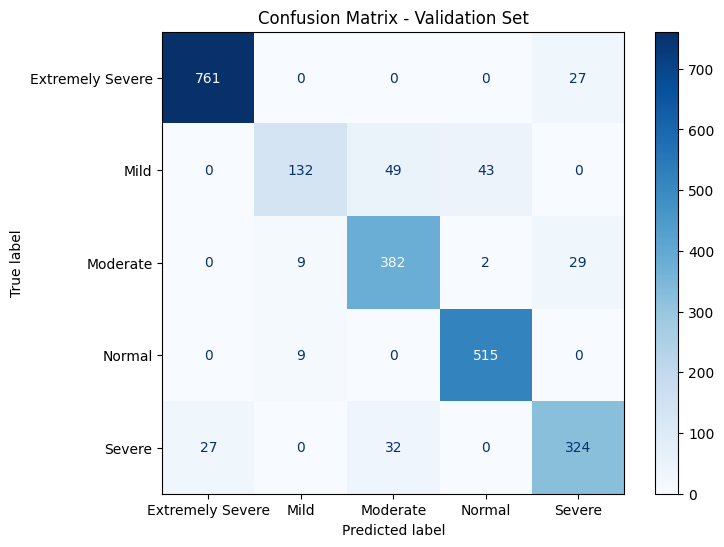

In [14]:
from sklearn.ensemble import RandomForestClassifier

# Assuming you already have X_train, y_train ready
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
le_target = LabelEncoder()
df['Condition'] = le_target.fit_transform(df['Condition'])

# STEP 1: Predict on validation set
y_pred = rf.predict(X_val)  # Assuming your model is 'rf'

# STEP 2: Decode label integers back to string class names (optional but clearer)
class_labels = le_target.inverse_transform(sorted(set(y_val)))  # Replace 'le_target' with your actual LabelEncoder for target

# STEP 3: Generate confusion matrix
cm = confusion_matrix(y_val, y_pred)

# STEP 4: Display the confusion matrix with class labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Validation Set")
plt.show()
